# Análisis de Movimiento Vehicular

**Procesamiento Digital de Imágenes — Universidad de Antioquia 2026-1**

## Integrantes

* Rafael Alemán
* Esteban
* Isabela Bedoya Gaviria

## Desarrollo

### Importaciones

In [ ]:
# ============================================================
# CELDA 1 — Importación de librerías
# ============================================================
# cv2      : OpenCV, librería principal de visión por computadora
# numpy    : operaciones matriciales y derivadas numéricas
# matplotlib: generación de gráficas cinemáticas
# cv2_imshow: versión de imshow compatible con Google Colab
# files    : utilidad de Colab para subir/bajar archivos

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow  # Específico para Colab
from google.colab import files
import numpy as np   # Para derivadas
import matplotlib.pyplot as plt  # Para gráficas


### Carga del Video

In [ ]:
# ============================================================
# CELDA 2 — Carga del video desde el PC local a Colab
# ============================================================
# files.upload() abre el selector de archivos del navegador.
# Retorna un dict {nombre_archivo: bytes}; tomamos la primera clave.

# Subir el video desde el PC al entorno de Colab
subido       = files.upload()
nombre_video = list(subido.keys())[0]
print(f'Video subido: {nombre_video}')


Saving video - Trim.mp4 to video - Trim.mp4
Video subido: video - Trim.mp4


In [ ]:
# ============================================================
# CELDA 3 — Lectura de metadatos del video y calibración de escala
# ============================================================
# Se abren los metadatos (FPS, resolución, nº de frames) y se cierra
# el capturador de inmediato para liberar el recurso.
#
# CALIBRACIÓN DE ESCALA (píxeles → metros):
#   Se mide en el primer frame la distancia en px de un objeto de
#   referencia conocido (ancho del carril ≈ 3.5 m en Colombia).
#   escala = distancia_real / distancia_pixeles  [m/px]
#
# PARÁMETROS DEL TRAMO A-B:
#   LINEA_A / LINEA_B: coordenadas Y (px) donde empieza y termina
#   el recorrido analizado. Todo lo que quede fuera se descarta.
#
# ZONA_X_MIN: columna mínima del carril de interés, evita confundir
#   el vehículo objetivo con otros en carriles adyacentes.
#
# FRAME_INI: primer frame donde el vehículo está completamente dentro
#   del tramo y el modelo de fondo MOG2 ya es estable.

# Abrir solo para leer metadatos y luego cerrar inmediatamente
cap = cv2.VideoCapture(nombre_video)
if not cap.isOpened():
    print('Error al abrir el video')
else:
    fps             = cap.get(cv2.CAP_PROP_FPS)
    num_frames      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ancho           = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    dt              = 1.0 / fps
    print(f'Video: {ancho}x{alto} | {fps} fps | {num_frames} frames')
cap.release()

# ── Calibración de escala ──────────────────────────────────────────────────────
# Ancho del carril derecho medido en el primer frame ≈ 180 px = 3.5 m (estándar Colombia)
distancia_real    = 3.5    # metros
distancia_pixeles = 180    # píxeles
escala            = distancia_real / distancia_pixeles  # m/px
area_minima       = 3000   # área mínima (px²) para considerar un contorno como vehículo

# ── Líneas A y B (coordenadas Y en píxeles) ────────────────────────────────────
# A: donde el vehículo entra al tramo; B: donde lo abandona.
LINEA_A    = 350   # px — borde superior del tramo
LINEA_B    = 920   # px — borde inferior del tramo

# ── Zona del vehículo de interés (carril curvo derecho) ───────────────────────
# El auto azul siempre transita con x > ZONA_X_MIN dentro del tramo A-B.
ZONA_X_MIN = 900   # px

# ── Frame de inicio del tracker ───────────────────────────────────────────────
# Se elige el primer frame donde el auto entra completamente al tramo A-B
# y el contorno MOG2 ya es estable (determinado inspeccionando el video).
FRAME_INI  = 32

print(f'Escala: {escala*100:.3f} cm/px  ({1/escala:.1f} px/m)')
print(f'Tramo A→B: y={LINEA_A} → y={LINEA_B}  ({(LINEA_B-LINEA_A)*escala:.2f} m estimados)')
print(f'Frame de inicio del tracker: {FRAME_INI} ({FRAME_INI/fps:.2f} s)')


Video: 1920x1080 | 30.025004429918685 fps | 305 frames
Escala: 1.944 cm/px  (51.4 px/m)
Tramo A→B: y=350 → y=920  (11.08 m estimados)
Frame de inicio del tracker: 32 (1.07 s)


### Visualización del primer frame con líneas A y B

Se confirma visualmente el posicionamiento de las líneas. Las zonas sombreadas quedan fuera del análisis cinemático.

In [ ]:
# ============================================================
# CELDA 4 — Visualización del primer frame con líneas A y B
# ============================================================
# Se superpone un rectángulo oscuro semitransparente sobre las zonas
# fuera del tramo A-B, y se dibujan las líneas de referencia en rojo
# (A) y verde (B). Sirve para validar visualmente los parámetros
# LINEA_A y LINEA_B antes de ejecutar el procesamiento completo.
# cv2.addWeighted() mezcla el overlay con el frame original.

cap = cv2.VideoCapture(nombre_video)
ret, primer_frame = cap.read()
cap.release()

if ret:
    vis_ref = primer_frame.copy()
    overlay = vis_ref.copy()
    cv2.rectangle(overlay, (0, 0),       (ancho, LINEA_A), (40, 40, 40), -1)
    cv2.rectangle(overlay, (0, LINEA_B), (ancho, alto),    (40, 40, 40), -1)
    cv2.addWeighted(overlay, 0.45, vis_ref, 0.55, 0, vis_ref)
    cv2.line(vis_ref, (0, LINEA_A), (ancho, LINEA_A), (0, 0, 255), 3)
    cv2.putText(vis_ref, f'A  (y={LINEA_A})', (40, LINEA_A - 14),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 0, 255), 3)
    cv2.line(vis_ref, (0, LINEA_B), (ancho, LINEA_B), (0, 200, 0), 3)
    cv2.putText(vis_ref, f'B  (y={LINEA_B})', (40, LINEA_B + 48),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 200, 0), 3)
    cv2_imshow(vis_ref)
    print('Zona de análisis: entre línea A y línea B (zona clara).')


### Preprocesamiento de Imagen

**Objetivo:** Reducir ruido antes de segmentar.

**Acción:** Convertir a escala de grises y aplicar filtro Gaussiano.

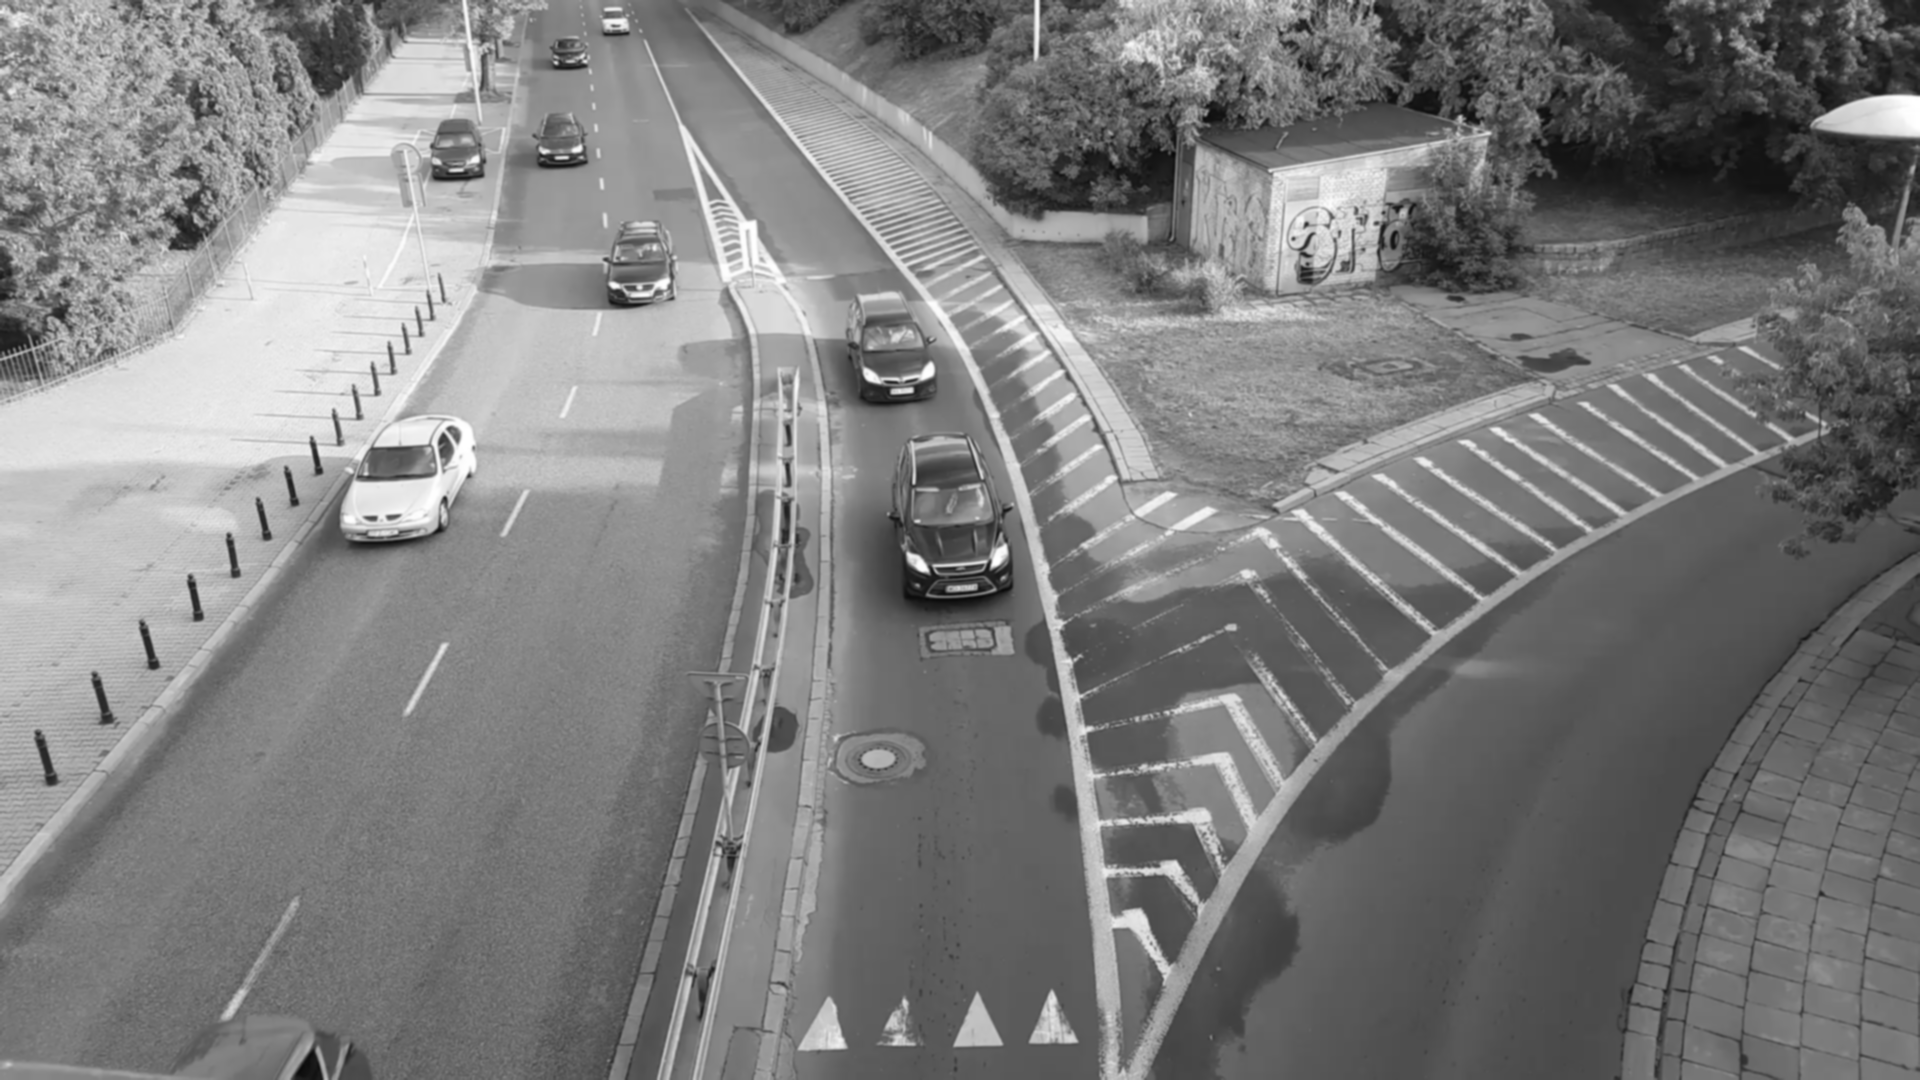

In [ ]:
# ============================================================
# CELDA 5 — Preprocesamiento: escala de grises y filtro Gaussiano
# ============================================================
# 1. cv2.cvtColor(BGR→GRAY): reduce el frame de 3 canales a 1,
#    eliminando información de color innecesaria para la segmentación.
# 2. GaussianBlur(kernel 5×5, σ=0): suaviza el ruido de la imagen
#    antes de la sustracción de fondo, reduciendo detecciones falsas.

# Cap nuevo: garantiza que frame no llega vacío sin importar el orden de ejecución
cap = cv2.VideoCapture(nombre_video)
ret, frame = cap.read()
cap.release()

gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gris, (5, 5), 0)
cv2_imshow(blur)


### Segmentación

**Objetivo:** Aislar el vehículo en movimiento del fondo estático.

**Método:** `cv2.createBackgroundSubtractorMOG2` modela el fondo de forma adaptativa. Se alimentan los primeros `FRAME_INI` frames para que aprenda el fondo antes de la detección. Los píxeles de sombra (valor 127) se eliminan con umbralamiento, conservando solo el primer plano (255).

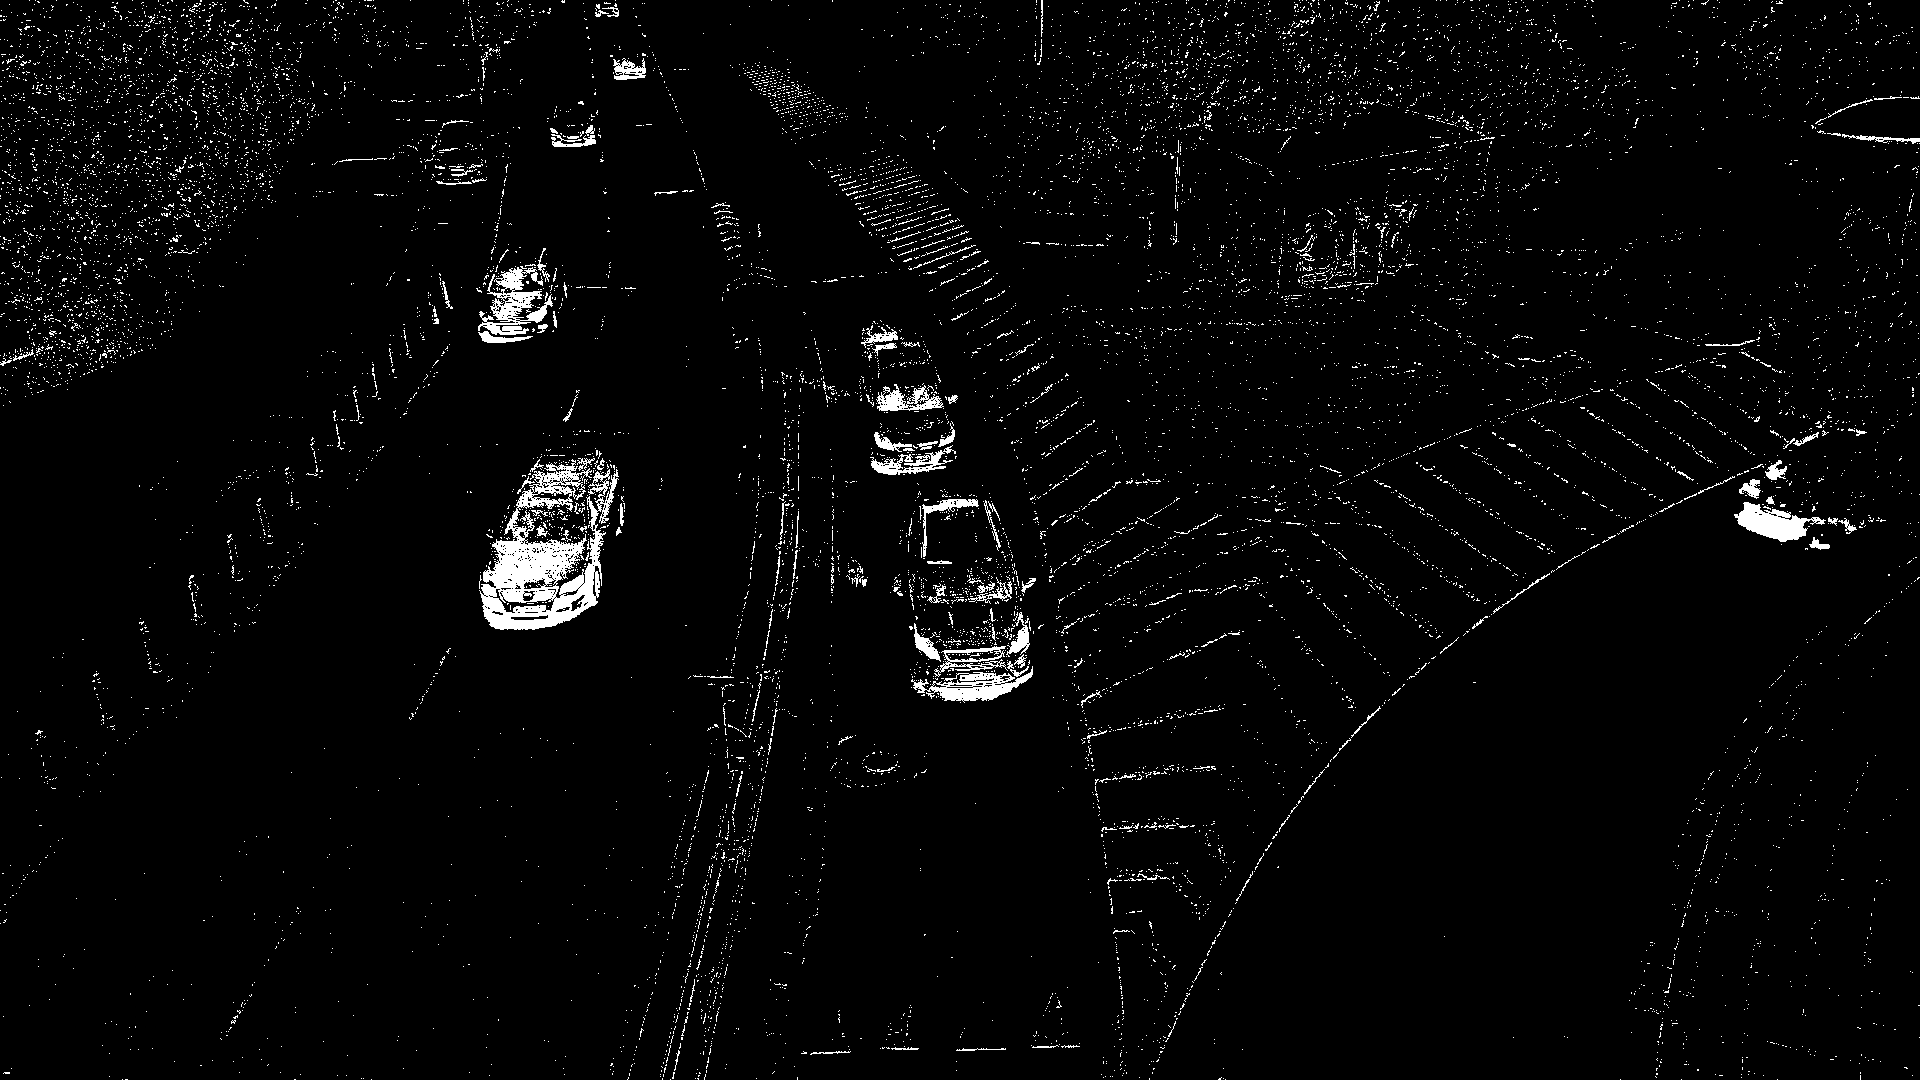

In [ ]:
# ============================================================
# CELDA 6 — Segmentación: sustracción de fondo con MOG2
# ============================================================
# BackgroundSubtractorMOG2 modela el fondo con una mezcla de
# gaussianas (Mixture of Gaussians), adaptándose a cambios de
# iluminación frame a frame.
#   history=500    : nº de frames usados para aprender el fondo
#   varThreshold=80: umbral de varianza para clasificar px como
#                    primer plano
#   detectShadows=True: marca sombras con valor 127 (gris)
#
# Se alimentan los primeros FRAME_INI frames para que el modelo
# aprenda el fondo antes de que entre el vehículo de interés.
#
# cv2.threshold(>200): elimina sombras (127) y conserva solo el
# primer plano real (255), generando una máscara binaria limpia.

# Sustracción de fondo MOG2: más robusto que umbral fijo
# porque se adapta automáticamente a cambios de iluminación frame a frame
sustractor = cv2.createBackgroundSubtractorMOG2(
    history=500, varThreshold=80, detectShadows=True
)

cap = cv2.VideoCapture(nombre_video)
for i in range(FRAME_INI + 1):  # aprender el fondo hasta el frame de inicio
    ret, frame = cap.read()
    if ret:
        mascara = sustractor.apply(frame)
cap.release()

# Eliminar sombras (valor 127 en MOG2), conservar solo primer plano (255)
_, mascara = cv2.threshold(mascara, 200, 255, cv2.THRESH_BINARY)

cv2_imshow(mascara)


### Morfología Matemática

**Objetivo:** Limpiar la máscara binaria y eliminar detecciones fuera del tramo A-B.

* **Apertura** (erosión → dilatación): elimina píxeles de ruido aislados.
* **Cierre** (dilatación → erosión): rellena huecos dentro del vehículo.
* **Dilatación** adicional: expande el blob para no perder bordes.
* **Erosión** final: recupera el tamaño original.
* **Enmascarado A-B**: pone a cero todo lo que esté fuera del tramo.

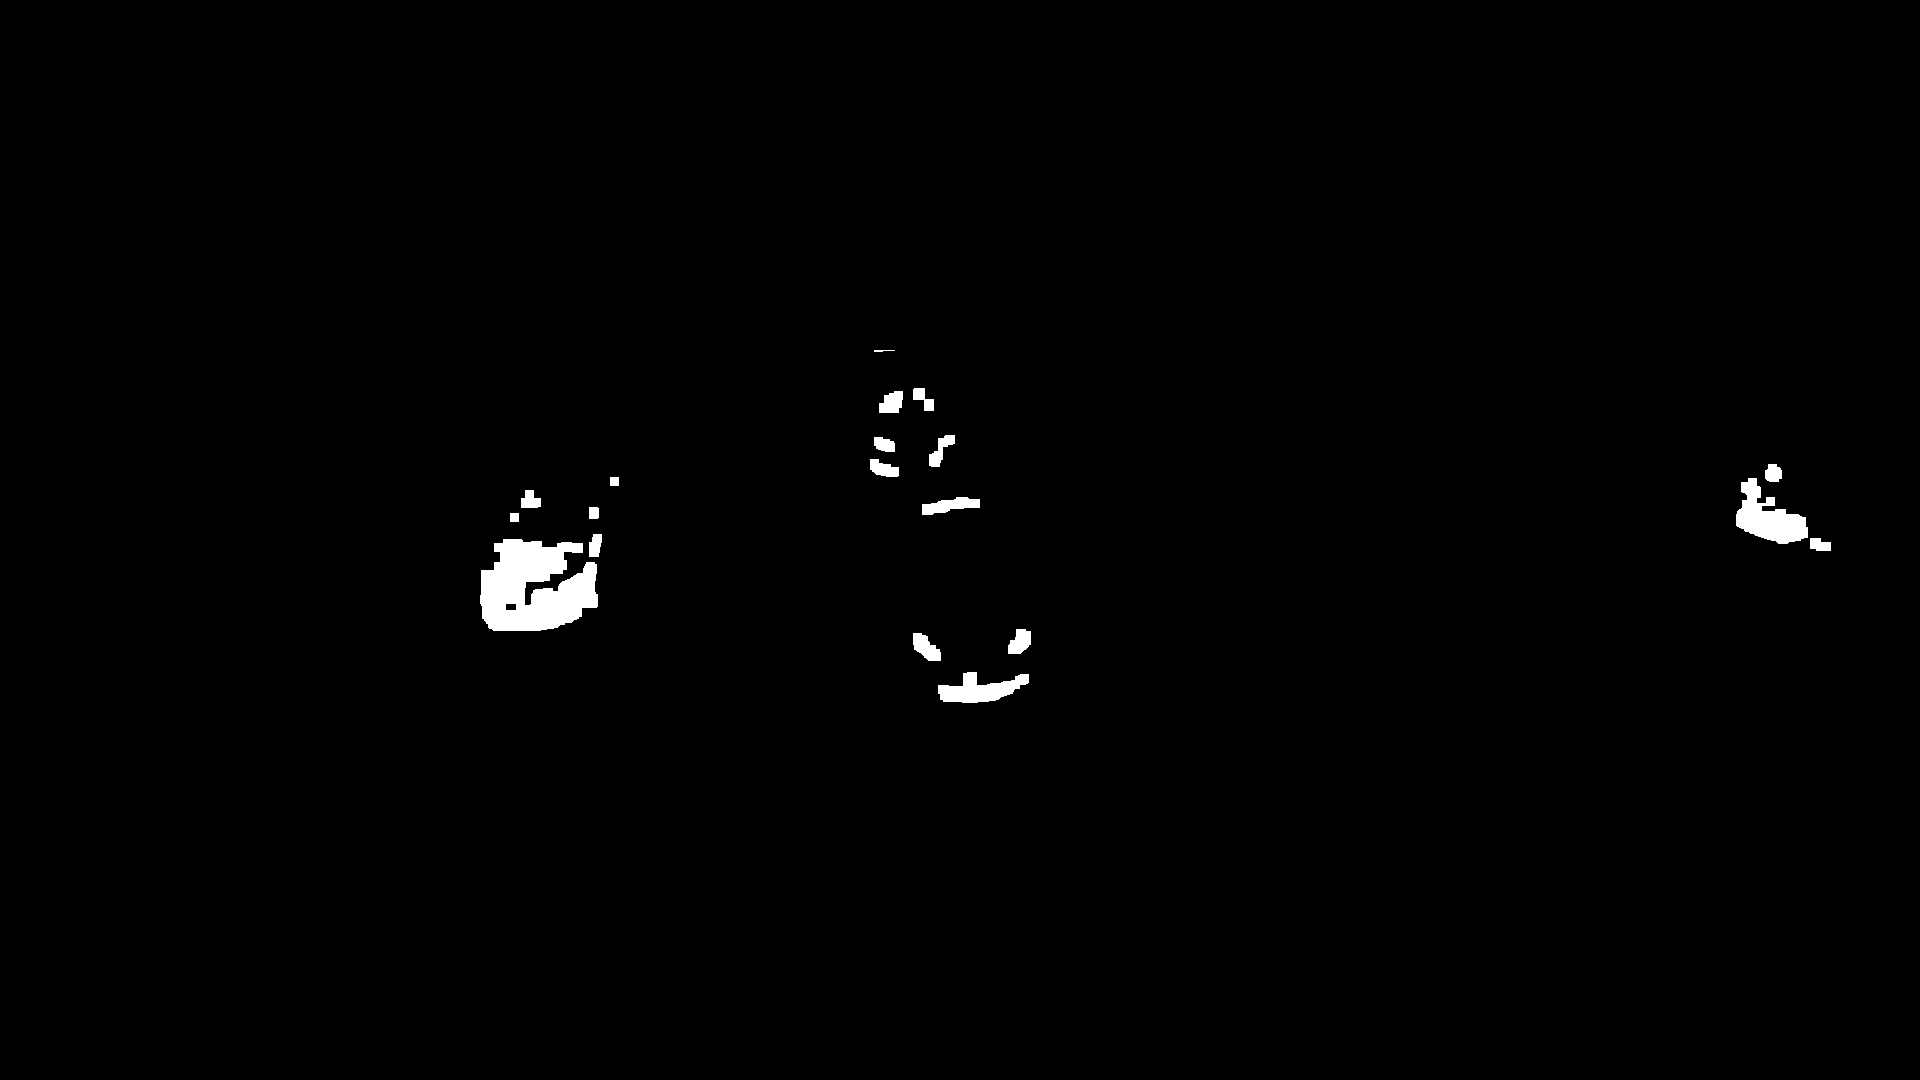

In [ ]:
# ============================================================
# CELDA 7 — Morfología matemática para limpiar la máscara binaria
# ============================================================
# Se aplica una secuencia de operaciones morfológicas con un
# elemento estructurante cuadrado de 5×5 píxeles:
#
#  1. MORPH_OPEN  (erosión → dilatación):
#     Elimina píxeles de ruido aislados (blobs pequeños falsos).
#
#  2. MORPH_CLOSE (dilatación → erosión):
#     Rellena huecos internos del vehículo causados por
#     ventanas, parabrisas u otras regiones homogéneas.
#
#  3. dilate (×2 iteraciones):
#     Expande el blob para capturar bordes que MOG2 pudo perder.
#
#  4. erode (×1 iteración):
#     Recupera el tamaño original tras la dilatación.
#
#  5. Enmascarado A-B:
#     Se ponen a cero todas las filas fuera del tramo de análisis,
#     eliminando cualquier detección espuria fuera de la zona.

kernel   = np.ones((5, 5), np.uint8)
apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,  kernel)  # elimina ruido pequeño
cierre   = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)  # rellena huecos
dilation = cv2.dilate(cierre, kernel, iterations=2)
erosion  = cv2.erode(dilation, kernel, iterations=1)

# Enmascarar fuera del tramo A-B: elimina ruido fuera de la zona de interés
erosion[:LINEA_A, :] = 0   # zona por encima de A → descartada
erosion[LINEA_B:,  :] = 0   # zona por debajo de B → descartada

cv2_imshow(erosion)


### Detección de Contornos y Cálculo del Centroide

**Objetivo:** Localizar el vehículo en `FRAME_INI` e inicializar el tracker sobre él.

1. Pipeline completo (MOG2 + morfología + enmascarado A-B) aplicado al frame `FRAME_INI`.
2. `cv2.findContours()` detecta bordes en la máscara.
3. Se filtra por `cv2.contourArea() > area_minima` y se restringe a `x > ZONA_X_MIN`.
4. `cv2.moments()` calcula el centroide exacto del contorno.
5. Se inicializa el tracker CSRT con ese bounding box.

In [ ]:
# ============================================================
# CELDA 8 — Detección de contornos, cálculo de centroide e
#            inicialización del tracker CSRT
# ============================================================
# Pipeline completo (MOG2 + morfología + enmascarado) aplicado
# al frame FRAME_INI para localizar el vehículo de interés.
#
# cv2.findContours():
#   RETR_EXTERNAL  : solo contornos externos (sin jerarquía)
#   CHAIN_APPROX_SIMPLE: comprime segmentos horizontales/verticales
#
# Filtrado por área y zona:
#   Se descartan contornos con área < area_minima para eliminar
#   ruido residual. Se restringe a x > ZONA_X_MIN para seleccionar
#   únicamente el carril del vehículo objetivo.
#
# cv2.moments():
#   Calcula los momentos estadísticos del contorno.
#   Centroide: cX = m10/m00,  cY = m01/m00
#   (m00 es el área del contorno en píxeles)
#
# cv2.TrackerCSRT_create():
#   CSRT (Channel and Spatial Reliability Tracking) es robusto a
#   cambios de escala y oclusiones parciales. Se inicializa con el
#   bounding rect del contorno más grande en FRAME_INI.

# Detectar el vehículo más grande en FRAME_INI con MOG2
# e inicializar el tracker CSRT sobre él.
# CSRT sigue ese vehículo específico sin saltar a otros.

sustractor2 = cv2.createBackgroundSubtractorMOG2(
    history=500, varThreshold=80, detectShadows=True
)

cap = cv2.VideoCapture(nombre_video)
for i in range(FRAME_INI + 1):
    ret, frame = cap.read()
    if ret:
        m = sustractor2.apply(frame)
        _, m = cv2.threshold(m, 200, 255, cv2.THRESH_BINARY)
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kernel)
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
        m = cv2.dilate(m, kernel, iterations=2)
        if i == FRAME_INI:
            frame_ini   = frame.copy()
            mascara_ini = m.copy()
cap.release()

# Enmascarar fuera del tramo A-B
mascara_ini[:LINEA_A, :] = 0
mascara_ini[LINEA_B:,  :] = 0

# Restringir la búsqueda a la zona derecha donde transita el auto de interés.
# Esto evita que se seleccione un vehículo del carril izquierdo con mayor área.
mascara_zona = mascara_ini.copy()
mascara_zona[:, :ZONA_X_MIN] = 0

# Encontrar contornos y seleccionar el más grande dentro de la zona de interés
contornos, _ = cv2.findContours(mascara_zona, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos    = [c for c in contornos if cv2.contourArea(c) > area_minima]
contornos    = sorted(contornos, key=cv2.contourArea, reverse=True)

c_ini        = contornos[0]
x, y, w, h   = cv2.boundingRect(c_ini)

# Calcular centroide con momentos de imagen
M = cv2.moments(c_ini)
if M['m00'] != 0:
    cX = int(M['m10'] / M['m00'])
    cY = int(M['m01'] / M['m00'])

# Inicializar tracker CSRT
tracker = cv2.TrackerCSRT_create()
tracker.init(frame_ini, (x, y, w, h))

vis = frame_ini.copy()
cv2.drawContours(vis, [c_ini], -1, (0, 255, 0), 2)
cv2.circle(vis, (cX, cY), 6, (0, 0, 255), -1)
cv2.line(vis, (0, LINEA_A), (ancho, LINEA_A), (0, 0, 255), 2)
cv2.putText(vis, f'A (y={LINEA_A})', (40, LINEA_A - 12),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 2)
cv2.line(vis, (0, LINEA_B), (ancho, LINEA_B), (0, 200, 0), 2)
cv2.putText(vis, f'B (y={LINEA_B})', (40, LINEA_B + 42),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 200, 0), 2)
print(f'Tracker iniciado en frame {FRAME_INI} ({FRAME_INI/fps:.2f} s) | centroide: ({cX}, {cY})')
print(f'Área del contorno: {cv2.contourArea(c_ini):.0f} px²')
cv2_imshow(vis)


Output hidden; open in https://colab.research.google.com to view.

### Tracking frame a frame y extracción de trayectoria

Se recorre el video desde `FRAME_INI`. En cada frame:

* El tracker CSRT actualiza la posición del bounding box.
* Se recalcula la máscara MOG2 del frame actual y se extrae el contorno real del auto para dibujarlo con su forma verdadera.
* Se guarda `(cX, cY)` **solo si `LINEA_A ≤ cY ≤ LINEA_B`**.
* Cuando el centroide sale del tramo A-B el tracker se detiene para evitar que siga erráticamente.

In [ ]:
# ============================================================
# CELDA 9 — Tracking frame a frame y extracción de trayectoria
# ============================================================
# Se recorre el video desde FRAME_INI. En cada frame:
#
#  1. tracker.update(frame): el algoritmo CSRT estima la nueva
#     posición del bounding box. Retorna ok=True si el tracking
#     es exitoso.
#
#  2. Centroide del bounding box:
#     cX = bx + bw//2,  cY = by + bh//2
#     Se usa el centro geométrico del bbox como aproximación al
#     centroide real del vehículo.
#
#  3. Condición de permanencia en tramo A-B:
#     Solo se guardan posiciones mientras LINEA_A ≤ cY ≤ LINEA_B.
#     Al salir del tramo, auto_visible = False detiene el tracking.
#
#  4. Contorno en tiempo real (sustractor3):
#     Se recalcula la máscara MOG2 frame a frame para dibujar el
#     contorno real del auto (no solo el bbox del tracker).
#
#  5. Trayectoria acumulada:
#     Se dibuja una línea que conecta todos los centroides previos
#     para visualizar el camino recorrido.
#
#  6. El video procesado se escribe en 'video_procesado.mp4'.

# Dibujar el contorno y un punto rojo en el centroide sobre el frame original y mostrarlo
posiciones_x  = []
posiciones_y  = []
indices_frame = []
trayectoria   = []
frame_muestra = None

# Preparar escritor del video de salida
fourcc    = cv2.VideoWriter_fourcc(*'mp4v')
video_out = cv2.VideoWriter('video_procesado.mp4', fourcc, fps, (ancho, alto))

# Sustractor adicional para extraer contorno real en cada frame
sustractor3 = cv2.createBackgroundSubtractorMOG2(
    history=500, varThreshold=80, detectShadows=True
)

cap = cv2.VideoCapture(nombre_video)
for i in range(FRAME_INI):   # avanzar al frame de inicio alimentando MOG2
    ret_tmp, frm_tmp = cap.read()
    sustractor3.apply(frm_tmp)

num_frame    = FRAME_INI
auto_visible = True   # mientras True, el auto está en el tramo A-B

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Máscara en tiempo real para obtener el contorno real del auto
    m_live = sustractor3.apply(frame)
    _, m_live = cv2.threshold(m_live, 200, 255, cv2.THRESH_BINARY)
    m_live = cv2.morphologyEx(m_live, cv2.MORPH_OPEN,  kernel)
    m_live = cv2.morphologyEx(m_live, cv2.MORPH_CLOSE, kernel)
    m_live = cv2.dilate(m_live, kernel, iterations=2)
    m_live[:LINEA_A, :] = 0
    m_live[LINEA_B:,  :] = 0
    m_zona = m_live.copy()
    m_zona[:, :ZONA_X_MIN] = 0

    if auto_visible:
        ok, bbox = tracker.update(frame)
        if ok:
            bx, by, bw, bh = [int(v) for v in bbox]
            cX = bx + bw // 2
            cY = by + bh // 2

            # Detener tracking cuando el centroide sale del tramo A-B
            if not (LINEA_A <= cY <= LINEA_B):
                auto_visible = False
            else:
                # Guardar posición solo mientras esté en el tramo
                posiciones_x.append(cX)
                posiciones_y.append(cY)
                indices_frame.append(num_frame)
                trayectoria.append((cX, cY))

                # Dibujar contorno real del auto desde la máscara MOG2
                conts_live, _ = cv2.findContours(m_zona, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                conts_live = [c for c in conts_live if cv2.contourArea(c) > area_minima]
                if conts_live:
                    conts_live = sorted(conts_live, key=cv2.contourArea, reverse=True)
                    cv2.drawContours(frame, [conts_live[0]], -1, (0, 255, 0), 2)

                cv2.circle(frame, (cX, cY), 6, (0, 0, 255), -1)
                for i in range(1, len(trayectoria)):
                    cv2.line(frame, trayectoria[i-1], trayectoria[i], (255, 100, 0), 2)

                if num_frame == FRAME_INI + 20:
                    frame_muestra = frame.copy()

    # Líneas A y B siempre visibles
    cv2.line(frame, (0, LINEA_A), (ancho, LINEA_A), (0, 0, 255), 2)
    cv2.putText(frame, f'A (y={LINEA_A})', (40, LINEA_A - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
    cv2.line(frame, (0, LINEA_B), (ancho, LINEA_B), (0, 200, 0), 2)
    cv2.putText(frame, f'B (y={LINEA_B})', (40, LINEA_B + 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 200, 0), 2)

    video_out.write(frame)
    num_frame += 1

cap.release()
video_out.release()
print(f'Frames rastreados dentro A-B: {len(posiciones_x)}')
print(f'Tiempo de análisis: {len(posiciones_x)/fps:.3f} s')

if frame_muestra is not None:
    cv2_imshow(frame_muestra)


Output hidden; open in https://colab.research.google.com to view.

### Análisis Cinemático (Derivación Numérica)

**Preparación de datos:** Convertir las listas de coordenadas $(x,y)$ a arrays de NumPy.

Como el vehículo sigue una trayectoria **curva/diagonal**, se calcula la **distancia euclidiana acumulada** entre centroides consecutivos:

$$s_k = \sum_{i=1}^{k} \sqrt{(\Delta x_i)^2 + (\Delta y_i)^2}$$

Esto mide el camino real recorrido, independientemente de la dirección, y produce siempre valores positivos.

**Cálculo de Velocidad:** derivada primera ($v = ds/dt$) por diferencias finitas hacia adelante entre fotogramas consecutivos.

**Cálculo de Aceleración:** derivada segunda numérica ($a = d^2s/dt^2$) por diferencias centradas.

In [ ]:
# ============================================================
# CELDA 10 — Análisis cinemático: posición, velocidad y aceleración
# ============================================================
# DISTANCIA EUCLIDIANA ACUMULADA:
#   Como el vehículo sigue una trayectoria curva/diagonal, se calcula
#   el desplazamiento real entre centroides consecutivos:
#     d_k = sqrt(Δx² + Δy²)
#   La posición acumulada s = Σ d_k mide el camino real en píxeles,
#   luego se convierte a metros con la escala de calibración.
#
# SELECCIÓN AUTOMÁTICA DEL MODELO CINEMÁTICO:
#   Se ajustan dos polinomios sobre s(t):
#     - Grado 1 → MRU  (velocidad constante)
#     - Grado 2 → MRUA (aceleración constante)
#   np.polyfit() minimiza el error cuadrático medio.
#   Se elige MRUA solo si mejora R² en > 0.01 Y la aceleración
#   candidata es físicamente razonable (< 5 m/s²).
#
# VELOCIDAD (derivada 1ª analítica):
#   np.polyder() calcula el polinomio derivado del ajuste.
#   v(t) = np.polyval(polyder(coef), t)
#   Esto evita el ruido inherente a las diferencias finitas brutas.
#
# ACELERACIÓN (derivada 2ª):
#   Para MRU  → a = 0  (constante)
#   Para MRUA → a = 2·coef[0]  (constante, del término cuadrático)

# Recortar la señal: quedarse solo con la parte estable
# Ajustar los índices según donde empiece y termine el tramo limpio
inicio = 0
fin    = len(posiciones_x)

dx = np.diff(posiciones_x)
dy = np.diff(posiciones_y)
distancias = np.sqrt(dx**2 + dy**2)           # distancia euclidiana entre frames consecutivos
pos_px     = np.concatenate([[0], np.cumsum(distancias)])  # posición acumulada en píxeles
pos_m      = pos_px * escala                   # convertir a metros

tiempo = np.array(indices_frame[inicio:fin], dtype=float) * dt
tiempo = tiempo - tiempo[0]                    # t=0 en el primer punto rastreado

# ── Selección automática de modelo cinemático ────────────────────────────────
# Se ajustan dos polinomios sobre la posición y se elige el modelo más simple
# que explique los datos. La derivada analítica del polinomio elegido da la
# velocidad y aceleración sin oscilaciones, independientemente del ruido del tracker.

def ajustar(t, s, grado):
    coef   = np.polyfit(t, s, grado)
    s_aj   = np.polyval(coef, t)
    ss_res = np.sum((s - s_aj)**2)
    ss_tot = np.sum((s - np.mean(s))**2)
    return coef, s_aj, 1 - ss_res/ss_tot

coef1, pos_mru,  r2_mru  = ajustar(tiempo, pos_m, 1)
coef2, pos_mrua, r2_mrua = ajustar(tiempo, pos_m, 2)

# Criterio de selección: se elige MRUA solo si mejora R² en más de 0.01
# y la aceleración calculada es físicamente razonable (< 5 m/s² para un auto en crucero).
# En caso contrario se reporta MRU (velocidad constante), que es más parsimonioso.
aceleracion_candidata = 2 * coef2[0]
mejora_r2             = r2_mrua - r2_mru

if mejora_r2 > 0.01 and abs(aceleracion_candidata) < 5.0:
    tipo_mov     = 'MRUA'
    coeficientes = coef2
    pos_suave    = pos_mrua
    r2           = r2_mrua
else:
    tipo_mov     = 'MRU'
    coeficientes = coef1
    pos_suave    = pos_mru
    r2           = r2_mru

velocities_x  = np.polyval(np.polyder(coeficientes), tiempo)
a_teorica     = 2 * coeficientes[0] if tipo_mov == 'MRUA' else 0.0
accelerations = np.full_like(tiempo, a_teorica)

# Mapa frame→velocidad para el video final
indices_recortados = indices_frame[inicio:fin]

print(f'Modelo seleccionado : {tipo_mov}  (mejora R²={mejora_r2:.4f})')
print(f'R² MRU              : {r2_mru:.4f}')
print(f'R² MRUA             : {r2_mrua:.4f}')
print(f'Velocidad media     : {np.mean(velocities_x):.3f} m/s  ({np.mean(velocities_x)*3.6:.2f} km/h)')
print(f'Aceleración modelo  : {a_teorica:.4f} m/s²')
print(f'Distancia total     : {pos_m[-1]:.2f} m')
print(f'Duración tramo      : {tiempo[-1]:.3f} s')


Modelo seleccionado : MRU  (mejora R²=0.0056)
R² MRU              : 0.9942
R² MRUA             : 0.9998
Velocidad media     : 9.005 m/s  (32.42 km/h)
Aceleración modelo  : 0.0000 m/s²
Distancia total     : 10.35 m
Duración tramo      : 1.132 s


**Cálculo de Aceleración:** Derivada segunda de la posición ($a = d^2s/dt^2$).

In [ ]:
# ============================================================
# CELDA 11 — Reimpresión de resultados del modelo cinemático
# ============================================================
# Los valores ya fueron calculados en la celda anterior.
# Esta celda solo los muestra como resumen de referencia rápida.

# La aceleración y el modelo cinemático ya fueron calculados en la celda anterior
# mediante el ajuste polinomial de grado 2 sobre la posición.
# Solo se reimprimen aquí para referencia:
print(f'Tipo de movimiento: {tipo_mov}')
print(f'Aceleración modelo: {a_teorica:.4f} m/s²')
print(f'R²: {r2:.4f}')


Tipo de movimiento: MRU
Aceleración modelo: 0.0000 m/s²
R²: 0.9942


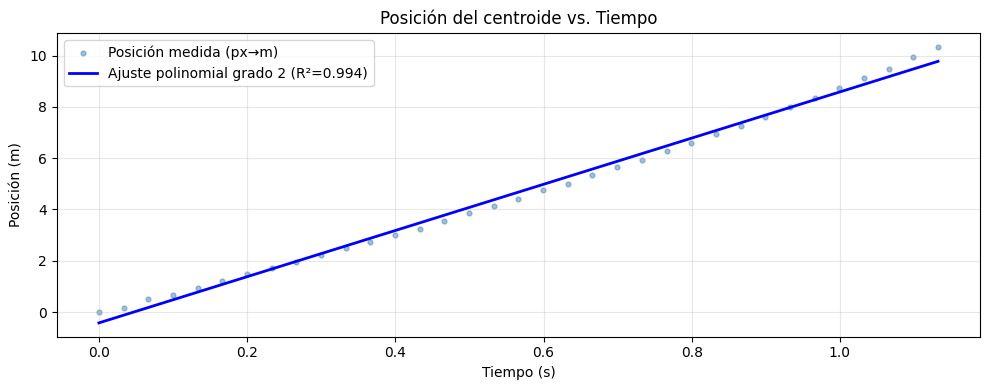

In [ ]:
# ============================================================
# CELDA 12 — Gráfica 1: Posición vs. Tiempo
# ============================================================
# scatter: puntos de posición medida experimentalmente (ruidosos)
# plot   : curva de ajuste polinomial suavizada
# Se muestra R² para cuantificar la bondad del ajuste al modelo.

# Gráfica 1: Posición vs. Tiempo.
plt.figure(figsize=(10, 4))
plt.scatter(tiempo, pos_m,    color='steelblue', s=12, alpha=0.5, label='Posición medida (px→m)')
plt.plot(tiempo, pos_suave,   'b-',  linewidth=2,   label=f'Ajuste polinomial grado 2 (R²={r2:.3f})')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición (m)')
plt.title('Posición del centroide vs. Tiempo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


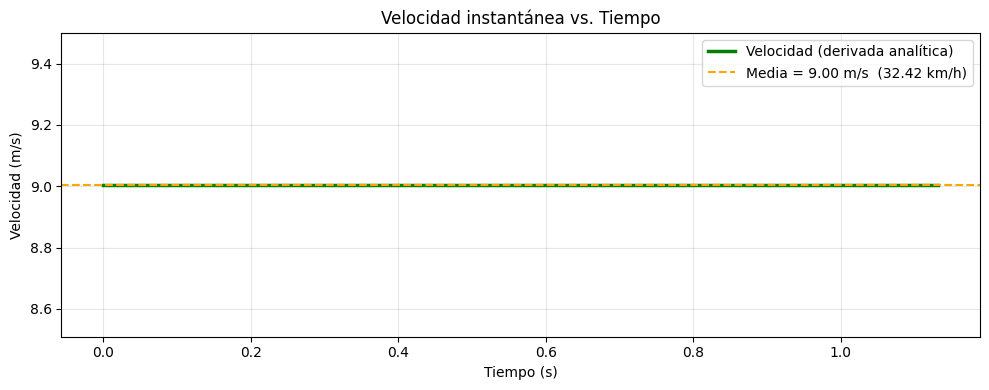

In [ ]:
# ============================================================
# CELDA 13 — Gráfica 2: Velocidad vs. Tiempo
# ============================================================
# Velocidad derivada analíticamente del polinomio de ajuste.
# axhline: línea de referencia con la velocidad media del tramo.
# La conversión m/s → km/h facilita la interpretación física.

# Gráfica 2: Velocidad vs. Tiempo.
plt.figure(figsize=(10, 4))
plt.plot(tiempo, velocities_x, 'g-', linewidth=2.5, label='Velocidad (derivada analítica)')
plt.axhline(np.mean(velocities_x), color='orange', linestyle='--',
            label=f'Media = {np.mean(velocities_x):.2f} m/s  ({np.mean(velocities_x)*3.6:.2f} km/h)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title('Velocidad instantánea vs. Tiempo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


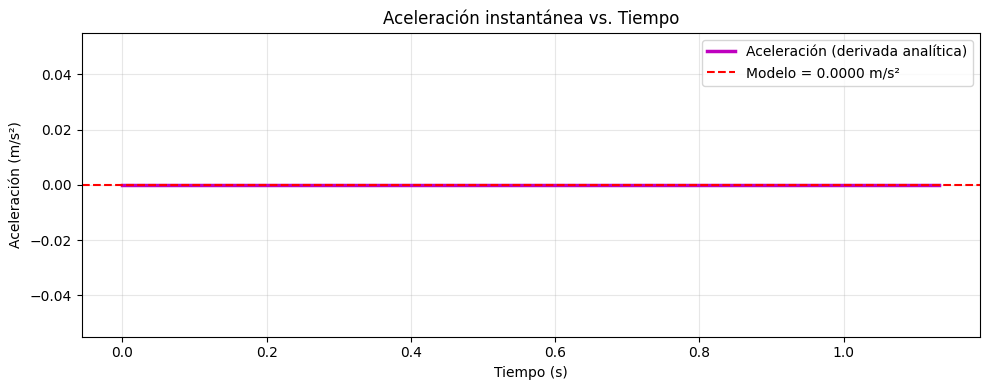

In [ ]:
# ============================================================
# CELDA 14 — Gráfica 3: Aceleración vs. Tiempo
# ============================================================
# Para MRU la aceleración es 0; para MRUA es constante = 2·coef[0].
# axhline: valor teórico del modelo elegido como línea de referencia.

# Gráfica 3: Aceleración vs. Tiempo.
plt.figure(figsize=(10, 4))
plt.plot(tiempo, accelerations, 'm-', linewidth=2.5, label='Aceleración (derivada analítica)')
plt.axhline(a_teorica, color='red', linestyle='--',
            label=f'Modelo = {a_teorica:.4f} m/s²')
plt.xlabel('Tiempo (s)')
plt.ylabel('Aceleración (m/s²)')
plt.title('Aceleración instantánea vs. Tiempo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Video final con velocidad superpuesta

Se regenera el video añadiendo la velocidad instantánea sobre cada frame y una barra de escala métrica.

In [ ]:
# ============================================================
# CELDA 15 — Generación del video final con anotaciones
# ============================================================
# Se hace una segunda pasada completa del video para escribir las
# siguientes anotaciones sobre cada frame:
#
#  · Contorno verde del vehículo (obtenido de MOG2 en tiempo real)
#  · Punto rojo en el centroide del tracker CSRT
#  · Trayectoria naranja acumulada de los centroides
#  · Texto amarillo con v [m/s] y v [km/h] en la esquina superior
#    (frame_vel: dict que mapea número de frame → velocidad)
#  · Líneas rojas/verdes de los puntos A y B siempre visibles
#  · Barra de escala blanca que representa 1 metro real
#    (px_1m = 1/escala, dibujada en la esquina inferior derecha)
#
# Se re-inicializa tracker2 y sustractor4 para garantizar una
# segunda pasada independiente y reproducible.

# Construir mapa frame → velocidad para la anotación
frame_vel = {fr: velocities_x[i] for i, fr in enumerate(indices_recortados)}

fourcc      = cv2.VideoWriter_fourcc(*'mp4v')
video_final = cv2.VideoWriter('video_final.mp4', fourcc, fps, (ancho, alto))

# Re-inicializar tracker para segunda pasada
tracker2 = cv2.TrackerCSRT_create()
tracker2.init(frame_ini, (x, y, w, h))

sustractor4 = cv2.createBackgroundSubtractorMOG2(
    history=500, varThreshold=80, detectShadows=True
)

cap = cv2.VideoCapture(nombre_video)
for i in range(FRAME_INI):
    ret_tmp, frm_tmp = cap.read()
    sustractor4.apply(frm_tmp)

tray2         = []
num_frame     = FRAME_INI
auto_visible2 = True

while True:
    ret, frame = cap.read()
    if not ret:
        break

    m2 = sustractor4.apply(frame)
    _, m2 = cv2.threshold(m2, 200, 255, cv2.THRESH_BINARY)
    m2 = cv2.morphologyEx(m2, cv2.MORPH_OPEN,  kernel)
    m2 = cv2.morphologyEx(m2, cv2.MORPH_CLOSE, kernel)
    m2 = cv2.dilate(m2, kernel, iterations=2)
    m2[:LINEA_A, :] = 0
    m2[LINEA_B:,  :] = 0
    m2z = m2.copy()
    m2z[:, :ZONA_X_MIN] = 0

    if auto_visible2:
        ok2, bbox2 = tracker2.update(frame)
        if ok2:
            bx2, by2, bw2, bh2 = [int(v) for v in bbox2]
            cX2 = bx2 + bw2 // 2
            cY2 = by2 + bh2 // 2

            if not (LINEA_A <= cY2 <= LINEA_B):
                auto_visible2 = False
            else:
                tray2.append((cX2, cY2))

                # Contorno real del auto
                conts2, _ = cv2.findContours(m2z, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                conts2 = [c for c in conts2 if cv2.contourArea(c) > area_minima]
                if conts2:
                    conts2 = sorted(conts2, key=cv2.contourArea, reverse=True)
                    cv2.drawContours(frame, [conts2[0]], -1, (0, 255, 0), 2)

                cv2.circle(frame, (cX2, cY2), 7, (0, 0, 255), -1)
                for i in range(1, len(tray2)):
                    cv2.line(frame, tray2[i-1], tray2[i], (255, 100, 0), 2)

                # Velocidad instantánea — siempre positiva (distancia acumulada)
                vel = frame_vel.get(num_frame, None)
                if vel is not None:
                    txt = f'v = {vel:.2f} m/s  ({vel*3.6:.1f} km/h)'
                    cv2.putText(frame, txt, (40, 60),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 0), 3)

    # Líneas A y B siempre visibles
    cv2.line(frame, (0, LINEA_A), (ancho, LINEA_A), (0, 0, 255), 2)
    cv2.putText(frame, f'A (y={LINEA_A})', (40, LINEA_A - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
    cv2.line(frame, (0, LINEA_B), (ancho, LINEA_B), (0, 200, 0), 2)
    cv2.putText(frame, f'B (y={LINEA_B})', (40, LINEA_B + 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 200, 0), 2)

    # Barra de escala (1 metro)
    px_1m = int(1.0 / escala)
    x0s, y0s = ancho - px_1m - 50, alto - 55
    cv2.line(frame, (x0s, y0s), (x0s + px_1m, y0s), (255, 255, 255), 3)
    cv2.putText(frame, '1 m', (x0s + px_1m // 2 - 22, y0s - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    video_final.write(frame)
    num_frame += 1

cap.release()
video_final.release()
print('Video final guardado: video_final.mp4')
files.download('video_final.mp4')


Video final guardado: video_final.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Descarga de archivos generados

In [ ]:
# ============================================================
# CELDA 16 — Descarga del video procesado
# ============================================================
# files.download() transfiere el archivo desde el entorno de Colab
# al sistema de archivos local del usuario.

files.download('video_procesado.mp4')
